## Classical clustering - performance evaluation 0

In [1]:
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ML").master("local[*]").getOrCreate()
spark.conf.set("spark.sql.ansi.enabled", False)

A couple of experiments with temporal features were carried out in this notebook, and final feature set corresponding to the result is described below:

For now we will ignore the order of logs inside individual sessions, we will one-hot categorical variables + month, we will aggregate countres by region, year contains only one value, so it will be ignored. Day number will be periodically transformed with sin + cos and price will be whitened, after we will apply PCA.

In [2]:
from utils.ml import prepare_data_pipeline, evaluate_clustering_model, data_dir
df_raw = spark.read.csv(data_dir, inferSchema=True, header=True, sep=";")
df, pipeline = prepare_data_pipeline(df_raw)

+-----+-------+-------------+------+--------+-----------------+-----+-------+----+------------+------------+-------+-------+
|month|country|main_category|colour|location|model photography|price|price 2|page|model_letter|model_number|day_sin|day_cos|
+-----+-------+-------------+------+--------+-----------------+-----+-------+----+------------+------------+-------+-------+
|    4|      0|            1|     1|       5|                1|   28|      2|   1|           A|          13|    0.0|    1.0|
|    4|      0|            1|     1|       6|                1|   33|      2|   1|           A|          16|    0.0|    1.0|
|    4|      0|            2|    10|       2|                1|   52|      1|   1|           B|           4|    0.0|    1.0|
|    4|      0|            2|     6|       6|                2|   38|      2|   1|           B|          17|    0.0|    1.0|
|    4|      0|            2|     4|       3|                2|   52|      1|   1|           B|           8|    0.0|    1.0|


## Evaluation

In [3]:
n_components = [30, 20, 15]
results = {"K-Means": [], "Bisecting KMeans": [], "GMM": []}

In [4]:
from pyspark.ml.clustering import BisectingKMeans, KMeans, GaussianMixture
import matplotlib.pyplot as plt
pca = pipeline.getStages()[-1]
for n in n_components:
    pca.setK(n)
    fitted = pipeline.fit(df)
    print("Explained Variance:", sum(fitted.stages[-1].explainedVariance))
    X = fitted.transform(df)
    results["K-Means"].append(evaluate_clustering_model(KMeans(maxIter=30), X, range(2, 21)))
    results["Bisecting KMeans"].append(evaluate_clustering_model(BisectingKMeans(maxIter=50), X, range(2, 21)))
    results["GMM"].append(evaluate_clustering_model(GaussianMixture(), X, range(2, 21)))


Explained Variance: 0.9011930614469904
Explained Variance: 0.8343227140413435
Explained Variance: 0.7515695002923418


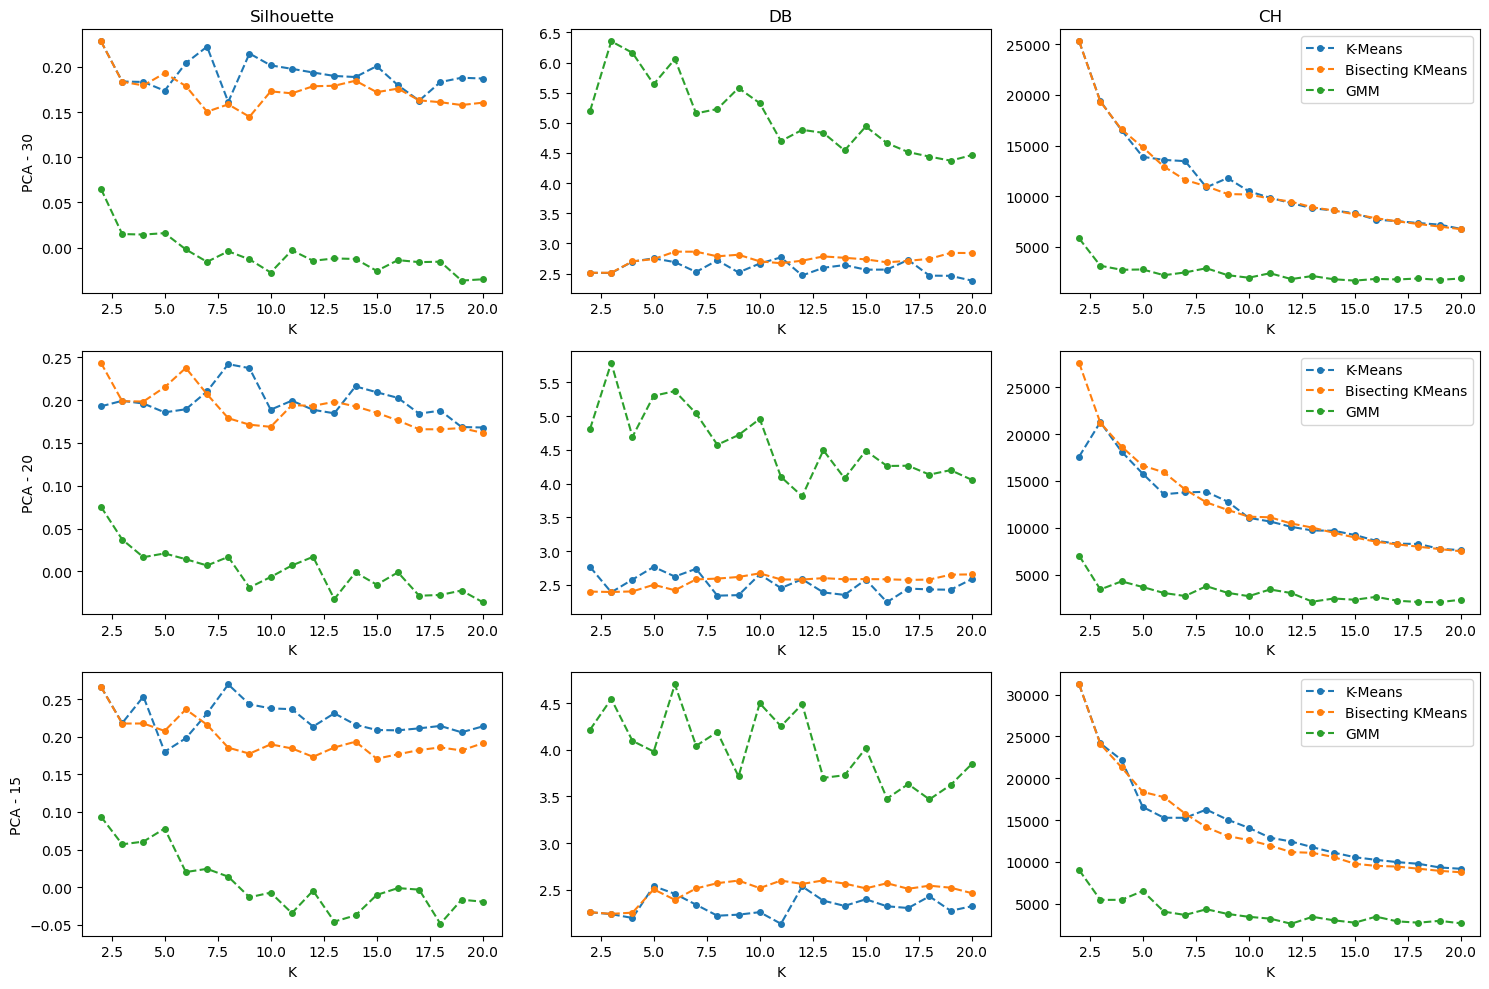

In [5]:
fig, ax = plt.subplots(3, 3, figsize=(15, 10), sharex=False)
models = list(results.keys())
scores = ["Silhouette", "DB", "CH"]
for r in range(3):
    for m in models:
        ax[r, 0].plot(results[m][r]["N_K"], results[m][r]["silouhette"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[r, 1].plot(results[m][r]["N_K"], results[m][r]["davies_bouldin"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[r, 2].plot(results[m][r]["N_K"], results[m][r]["calinski_harabasz"], label= m, linestyle = "--", marker = "o", markersize = 4)
    for c in range(3):
        ax[r, c].set_xlabel("K")
        if r == 0:
            ax[r, c].set_title(scores[c])
        if c == 0:
            ax[r, c].set_ylabel(f"PCA - {n_components[r]}")
        if c == 2:
            ax[r, c].legend()
plt.tight_layout()
plt.show()

In [6]:
import json
with open('result.json', 'w') as fp:
    json.dump(results, fp)

## Conclusion

Temporal features carry minimal meaning in this dataset.